<a href="https://colab.research.google.com/github/shawnfrancis578-collab/shawnfrancis578-collab.github.io/blob/main/Shawn_Practical_4_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 4: LSTM Encoder–Decoder for Sequence-to-Sequence Learning

**Name:** Shawn Francis  
**Aim:** To implement an LSTM-based encoder–decoder architecture for sequence-to-sequence learning.

## Theory
A sequence-to-sequence (Seq2Seq) model converts one sequence into another sequence. It contains two main components:

1. **Encoder:** reads the input sequence and converts it into hidden and cell states.
2. **Decoder:** uses the encoder states to generate the output sequence one token at a time.

During training, the correct previous output token is supplied to the decoder. This technique is called **teacher forcing**. In this experiment, the network learns to reverse a sequence of numbers.

In [1]:
!pip -q install tensorflow matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## Step 1: Generate sequence data
The input contains five tokens. The required target is the same sequence in reverse order. Token `7` is reserved as the start-of-sequence (SOS) token.

In [3]:
NUM_SAMPLES = 3000
SEQUENCE_LENGTH = 5
DATA_TOKEN_COUNT = 6       # Ordinary tokens: 1 to 6
SOS_TOKEN = 7              # Separate start token
VOCABULARY_SIZE = 8        # Indices 0 to 7

encoder_token_data = np.random.randint(
    1, DATA_TOKEN_COUNT + 1, size=(NUM_SAMPLES, SEQUENCE_LENGTH)
)
target_token_data = np.flip(encoder_token_data, axis=1)

# Decoder input begins with SOS and then receives the previous target token.
decoder_token_data = np.zeros_like(target_token_data)
decoder_token_data[:, 0] = SOS_TOKEN
decoder_token_data[:, 1:] = target_token_data[:, :-1]

print('Input sequence:        ', encoder_token_data[0])
print('Decoder input sequence:', decoder_token_data[0])
print('Expected output:       ', target_token_data[0])

Input sequence:         [4 5 3 5 5]
Decoder input sequence: [7 5 5 3 5]
Expected output:        [5 5 3 5 4]


## Step 2: Convert token sequences into one-hot vectors

In [4]:
encoder_input_data = to_categorical(
    encoder_token_data, num_classes=VOCABULARY_SIZE
).astype('float32')
decoder_input_data = to_categorical(
    decoder_token_data, num_classes=VOCABULARY_SIZE
).astype('float32')
decoder_target_data = to_categorical(
    target_token_data, num_classes=VOCABULARY_SIZE
).astype('float32')

print('Encoder input shape:', encoder_input_data.shape)
print('Decoder input shape:', decoder_input_data.shape)
print('Decoder target shape:', decoder_target_data.shape)

Encoder input shape: (3000, 5, 8)
Decoder input shape: (3000, 5, 8)
Decoder target shape: (3000, 5, 8)


## Step 3: Build the LSTM encoder–decoder model

In [5]:
LATENT_DIMENSION = 64

# Encoder
encoder_inputs = Input(shape=(None, VOCABULARY_SIZE), name='encoder_inputs')
encoder_lstm = LSTM(LATENT_DIMENSION, return_state=True, name='encoder_lstm')
_, encoder_state_h, encoder_state_c = encoder_lstm(encoder_inputs)
encoder_states = [encoder_state_h, encoder_state_c]

# Decoder
decoder_inputs = Input(shape=(None, VOCABULARY_SIZE), name='decoder_inputs')
decoder_lstm = LSTM(
    LATENT_DIMENSION, return_sequences=True, return_state=True,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs, initial_state=encoder_states
)
decoder_dense = Dense(VOCABULARY_SIZE, activation='softmax', name='output_layer')
decoder_outputs = decoder_dense(decoder_outputs)

training_model = Model(
    [encoder_inputs, decoder_inputs], decoder_outputs,
    name='lstm_encoder_decoder'
)
training_model.compile(
    optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
)
training_model.summary()

Model: "lstm_encoder_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None, 8)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None, 8)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     18,688 │ encoder_inputs[0… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     18,688 │ decoder_inputs[0… │
│                     │ 64), (None, 64),  │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, None, 8)   │        520 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,896 (148.03 KB)

 Trainable params: 37,896 (148.03 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the model

In [6]:
history = training_model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print('Training completed successfully.')
print(f'Final training accuracy:   {history.history["accuracy"][-1]:.4f}')
print(f'Final validation accuracy: {history.history["val_accuracy"][-1]:.4f}')

Training completed successfully.
Final training accuracy:   1.0000
Final validation accuracy: 1.0000


## Step 5: Plot training performance

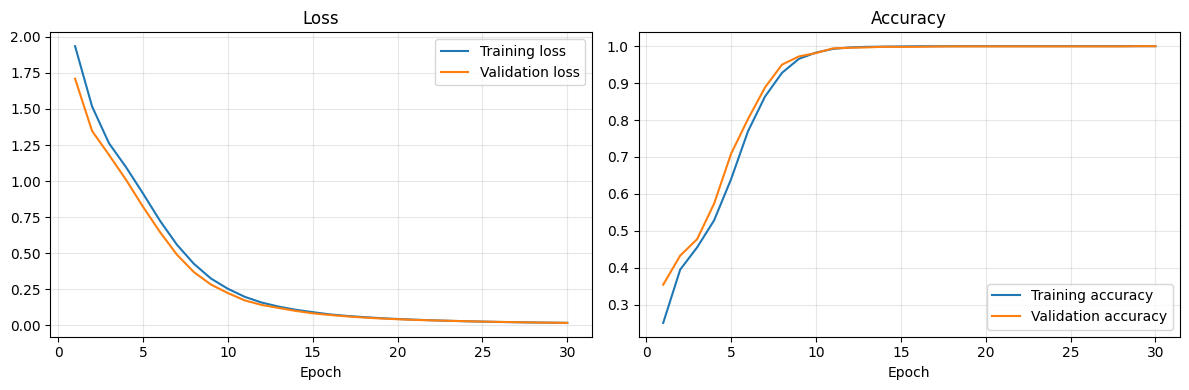

In [7]:
epochs = range(1, len(history.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.history['loss'], label='Training loss')
axes[0].plot(epochs, history.history['val_loss'], label='Validation loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Training accuracy')
axes[1].plot(epochs, history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Create inference models
During inference, the encoder processes the complete input once. The decoder then generates one output token at a time and reuses its updated LSTM states.

In [8]:
encoder_model = Model(
    encoder_inputs, encoder_states, name='encoder_inference_model'
)

decoder_state_input_h = Input(shape=(LATENT_DIMENSION,), name='decoder_state_h')
decoder_state_input_c = Input(shape=(LATENT_DIMENSION,), name='decoder_state_c')
decoder_state_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inference_output, state_h, state_c = decoder_lstm(
    decoder_inputs, initial_state=decoder_state_inputs
)
decoder_inference_output = decoder_dense(decoder_inference_output)

decoder_model = Model(
    [decoder_inputs] + decoder_state_inputs,
    [decoder_inference_output, state_h, state_c],
    name='decoder_inference_model'
)

print('Encoder and decoder inference models created.')

Encoder and decoder inference models created.


## Step 7: Generate output sequences

In [9]:
def decode_sequence(input_tokens):
    input_tokens = np.asarray(input_tokens, dtype='int32').reshape(1, -1)
    input_vector = to_categorical(
        input_tokens, num_classes=VOCABULARY_SIZE
    ).astype('float32')

    states = encoder_model.predict(input_vector, verbose=0)
    target_vector = np.zeros((1, 1, VOCABULARY_SIZE), dtype='float32')
    target_vector[0, 0, SOS_TOKEN] = 1.0
    decoded_tokens = []

    for _ in range(SEQUENCE_LENGTH):
        output, state_h_value, state_c_value = decoder_model.predict(
            [target_vector] + states, verbose=0
        )
        predicted_token = int(np.argmax(output[0, -1, :]))
        decoded_tokens.append(predicted_token)

        target_vector.fill(0.0)
        target_vector[0, 0, predicted_token] = 1.0
        states = [state_h_value, state_c_value]

    return decoded_tokens

test_sequences = [
    [1, 2, 3, 4, 5],
    [6, 2, 1, 5, 3],
    [4, 4, 2, 6, 1]
]

for sequence in test_sequences:
    expected = sequence[::-1]
    predicted = decode_sequence(sequence)
    print(f'Input: {sequence} | Expected: {expected} | Predicted: {predicted}')

Input: [1, 2, 3, 4, 5] | Expected: [5, 4, 3, 2, 1] | Predicted: [5, 4, 3, 2, 1]
Input: [6, 2, 1, 5, 3] | Expected: [3, 5, 1, 2, 6] | Predicted: [3, 5, 1, 2, 6]
Input: [4, 4, 2, 6, 1] | Expected: [1, 6, 2, 4, 4] | Predicted: [1, 6, 2, 4, 4]


## Step 8: Calculate exact-sequence accuracy

In [10]:
correct_predictions = 0
number_of_tests = 50

for sequence in encoder_token_data[-number_of_tests:]:
    prediction = decode_sequence(sequence)
    if prediction == sequence[::-1].tolist():
        correct_predictions += 1

exact_accuracy = correct_predictions / number_of_tests
print(f'Exact sequence accuracy: {exact_accuracy:.2%}')

Exact sequence accuracy: 100.00%


## Result
The LSTM encoder–decoder learned to convert an input sequence into its reversed output sequence. The encoder produced hidden and cell states, while the decoder generated the output tokens sequentially.

## Conclusion
Thus, an LSTM-based encoder–decoder architecture was successfully implemented for sequence-to-sequence learning. Teacher forcing was used during training, and separate encoder and decoder inference models were used to generate output sequences one token at a time.